# USE Case - Trendy or not?

In Dec 27 2021 I saw this artilce on Bllomberg that says that Oculus demand is going up for Holidays.  How can we verify that?

https://www.bloomberg.com/news/articles/2021-12-27/meta-advances-as-keybanc-sees-strong-holiday-sales-for-oculus


# Try pytrends

### Unofficial API for Google Trends

Allows simple interface for automating downloading of reports from Google Trends. Only good until Google changes their backend again :-P. When that happens feel free to contribute!

https://towardsdatascience.com/google-trends-api-for-python-a84bc25db88f
https://github.com/GeneralMills/pytrends
https://pypi.org/project/pytrends/

In [1]:
!pip install pytrends

## Import

In [63]:
import pandas as pd                        
import matplotlib.pyplot as plt
import numpy as np


from pytrends.request import TrendReq

## Connect to Google

In [6]:
pytrend = TrendReq()

## Get trend data for Oculus

https://trends.google.com/trends/explore?geo=US&q=oculus

In [7]:
search_query = "Oculus"

In [8]:
pytrend.build_payload(kw_list=[search_query])

# Interest by Region
df = pytrend.interest_by_region()
df.head(10)

,Oculus
geoName,
Afghanistan,0
Albania,0
Algeria,0
American Samoa,0
Andorra,0
Angola,0
Anguilla,0
Antarctica,0
Antigua & Barbuda,0


In [9]:
df.reset_index().plot(x='geoName', y=search_query, figsize=(120, 10), kind ='bar')

In [10]:
# Get Google Hot Trends data
df = pytrend.trending_searches(pn='united_states')
df.head()

,0
0,Dallas Cowboys
1,Eagles
2,Houston Texans
3,Liverpool vs Man City
4,Penn State


In [11]:
df = pytrend.today_searches(pn='US')

In [12]:
df.head(10)

0    /trends/explore?q=Dallas+Cowboys&date=now+7-d&...
1    /trends/explore?q=Penn+State+Football&date=now...
2         /trends/explore?q=Eagles&date=now+7-d&geo=US
3    /trends/explore?q=Kentucky+football&date=now+7...
4      /trends/explore?q=Liverpool&date=now+7-d&geo=US
5    /trends/explore?q=Rennes+vs+PSG&date=now+7-d&g...
6    /trends/explore?q=Houston+Texans&date=now+7-d&...
7    /trends/explore?q=Emily+Ratajkowski&date=now+7...
8    /trends/explore?q=Lions+vs+Bears&date=now+7-d&...
9    /trends/explore?q=Browns+vs+Vikings&date=now+7...
Name: exploreLink, dtype: object

## Let's try the query again

In [56]:
kw_list = ['Oculus']
time_range = '2021-11-01 2021-12-27'

pytrend.build_payload(kw_list, cat=0, timeframe=time_range, geo='US', gprop='')

In [57]:
# Interest over time
df = pytrend.interest_over_time()
df.tail(10)

,Oculus,isPartial
date,,
2021-12-16,12,False
2021-12-17,12,False
2021-12-18,16,False
2021-12-19,16,False
2021-12-20,16,False
2021-12-21,16,False
2021-12-22,16,False
2021-12-23,19,False
2021-12-24,25,False


## Convert index to date column

In [58]:
df.reset_index(level=0, inplace=True)
df.date = pd.to_datetime(df['date']).apply(lambda x: x.date())

## Plot the time series graph

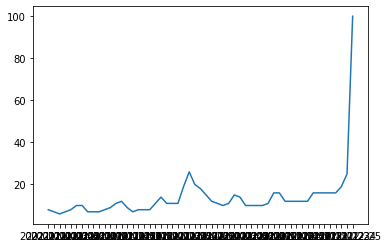

In [59]:
x = [t.strftime('%Y-%m-%d') for t in df.date.values.tolist()]
y = df.Oculus.tolist()

plt.plot(x,y)
plt.show()

## Trendy or not

In [61]:
# Compute 7 day average slop over time

slopes = []
win = 7
for inx in range(win-1, len(y)):
    slope = y[inx] - y[inx-win+1]
    slopes.append(slope)

## Compute mean & std

In [64]:
mean = np.mean(np.array(y))
std = np.std(np.array(y))

## Is the recent samples are more than 2 * std above mean?

Assuming Gausssian distribution

In [67]:
k = 2  # how many standard deviation from mean
recent_window = 7
trendy = False

for y_val in y[len(y) - recent_window:]:
    if y_val >= mean + k*std:
        trendy = True
        break

## Trendy?

In [68]:
if trendy:
    print("Trending!")
else:
    print("Not trending :(")

Trending!


## Conclusion

`This confirms Bloomberg article point`